# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Salma Perbiana
- **Email:** cdcc200d6x2466@student.devacademy.id
- **ID Dicoding:** CDCC200D6X2466

### Pertanyaan Bisnis

- **Pertanyaan 1:** Seberapa besar perbedaan rata-rata jumlah penyewaan sepeda (cnt) antara kondisi cuaca buruk (weathersit ≥ 3) dan cuaca normal (weathersit < 3) pada data per jam selama tahun 2011–2012?
- **Pertanyaan 2:** Pada jam berapa terjadi jumlah penyewaan tertinggi oleh pengguna registered pada hari kerja selama musim panas (summer) tahun 2011-2012?
- **Pertanyaan 3:** Bagaimana perbedaan rata-rata jumlah penyewaan sepeda antara pengguna casual dan registered pada akhir pekan (weekend) selama tahun 2011-2012?
- **Pertanyaan 4:** Bagaimana hubungan antara suhu (temp) dan jumlah penyewaan sepeda (cnt) pada kondisi suhu rendah dan tinggi selama tahun 2011–2012?

## Import Semua Packages/Library yang Digunakan

In [307]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load Dataset day

In [308]:
day_df = pd.read_csv("https://raw.githubusercontent.com/salmaperbiana/Bike-Sharing-Data/refs/heads/main/day.csv")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


#### Load Dataset Hour

In [309]:
hour_df = pd.read_csv("https://raw.githubusercontent.com/salmaperbiana/Bike-Sharing-Data/refs/heads/main/hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


*   Dataset yang digunakan adalah Bike Sharing Dataset yang terdiri dari data harian (day_df) dan data per jam (hour_df).
*   Terdapat variabel yang cukup lengkap seperti cuaca (weathersit, temp, hum, windspeed) dan kalender (season, weekday, holiday, workingday) yang berpotensi memengaruhi jumlah penyewaan sepeda (cnt).
*   Dataset membedakan pengguna menjadi casual dan registered, sehingga memungkinkan analisis perilaku pengguna berdasarkan tipe pelanggan.
*   Terdapat normalisasi pada variabel cuaca (temp, atemp, hum, windspeed), sehingga perlu perhatian khusus jika ingin interpretasi dalam satuan asli.
*   Dataset memiliki cakupan waktu tahun 2011–2012, sehingga memungkinkan analisis tren musiman, tetapi terbatas untuk analisis jangka panjang.



### Assessing Data


#### Identifying Statistic

In [310]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [311]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


#### Identifying Data

In [312]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [313]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


**Steps to Take:**
1. Kolom dteday perlu dikonversi ke format datetime agar dapat digunakan untuk analisis berbasis waktu.
2. Beberapa kolom kategorikal (season, yr, weathersit, workingday) dapat diubah menjadi tipe kategori agar lebih sesuai untuk analisis dan pemodelan.

**Insight:** (Opsional)
Hasil pengecekan menunjukkan bahwa dataset sudah cukup lengkap untuk dianalisis lebih lanjut, terutama dalam memahami pola penggunaan sepeda berdasarkan faktor waktu, cuaca, dan musim.

#### Identifying Missing Value Problem

In [314]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [315]:
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


**Steps to Take:**
1. Tidak diperlukan penanganan missing value karena seluruh kolom memiliki nilai lengkap (tidak terdapat nilai null).
2. Data dapat langsung digunakan untuk proses analisis selanjutnya.

**Insight:** (Opsional)
Hasil pengecekan menunjukkan bahwa dataset dalam kondisi baik tanpa adanya missing value, sehingga tidak diperlukan proses imputasi atau penghapusan data.


#### Identifying Duplicate Problem

In [316]:
print("Jumlah duplikasi: ", day_df.duplicated().sum())

Jumlah duplikasi:  0


In [317]:
print("Jumlah duplikasi: ", hour_df.duplicated().sum())

Jumlah duplikasi:  0


**Steps to Take:**
1. Tidak diperlukan penanganan duplicate data.
2. Data dapat langsung digunakan untuk proses analisis selanjutnya.

**Insight:** (Opsional)
Hasil pengecekan menunjukkan bahwa tidak terdapat data duplikat pada kedua dataset (day_df dan hour_df). Oleh karena itu, tidak diperlukan proses penghapusan data duplikat.


#### Identifying Outlier Problem

In [318]:
cols = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']

for col in cols:
    q25, q75 = np.percentile(day_df[col], 25), np.percentile(day_df[col], 75)
    iqr = q75 - q25

    lower = q25 - 1.5 * iqr
    upper = q75 + 1.5 * iqr

    outliers = day_df[(day_df[col] < lower) | (day_df[col] > upper)]

    print(f"day_df - {col}: {len(outliers)} outliers")

day_df - temp: 0 outliers
day_df - atemp: 0 outliers
day_df - hum: 2 outliers
day_df - windspeed: 13 outliers
day_df - cnt: 0 outliers


In [319]:
for col in cols:
    q25, q75 = np.percentile(hour_df[col], 25), np.percentile(hour_df[col], 75)
    iqr = q75 - q25

    lower = q25 - 1.5 * iqr
    upper = q75 + 1.5 * iqr

    outliers = hour_df[(hour_df[col] < lower) | (hour_df[col] > upper)]

    print(f"hour_df - {col}: {len(outliers)} outliers")

hour_df - temp: 0 outliers
hour_df - atemp: 0 outliers
hour_df - hum: 22 outliers
hour_df - windspeed: 342 outliers
hour_df - cnt: 505 outliers


**Steps to Take:**
1. Melakukan identifikasi outlier pada kedua dataset (day_df dan hour_df) menggunakan metode Interquartile Range (IQR) pada kolom numerik seperti temp, atemp, hum, windspeed, dan cnt.
  * Pengecekan outlier hanya dilakukan pada variabel numerik tertentu, yaitu temp, atemp, hum, windspeed, dan cnt karena variabel-variabel tersebut merupakan faktor utama yang berpotensi memengaruhi jumlah penyewaan sepeda. Variabel seperti season, weekday, weathersit, dan hr tidak dianalisis sebagai outlier karena bersifat kategorikal atau diskrit, sehingga tidak memiliki makna distribusi kontinu yang relevan untuk metode IQR. Selain itu, fokus analisis ini adalah memahami faktor yang memengaruhi jumlah penyewaan sepeda, sehingga hanya variabel numerik yang memiliki hubungan langsung dengan perilaku pengguna yang diprioritaskan dalam analisis outlier.
2. Membandingkan jumlah outlier pada masing-masing kolom untuk memahami distribusi data.
3. Mengevaluasi apakah outlier merupakan kesalahan data atau variasi alami dari aktivitas penyewaan sepeda.
4. Memutuskan untuk tidak menghapus outlier karena sebagian besar outlier kemungkinan mencerminkan kondisi nyata seperti perubahan cuaca ekstrem atau lonjakan penggunaan sepeda pada waktu tertentu.

**Insight:** (Opsional)
Hasil analisis menunjukkan bahwa tidak terdapat outlier pada variabel suhu (temp dan atemp) di kedua dataset, yang mengindikasikan distribusi data suhu relatif stabil.

Namun, ditemukan outlier pada beberapa variabel lain:
- Pada day_df, outlier ditemukan pada hum (2 data) dan windspeed (13 data).
- Pada hour_df, outlier lebih banyak ditemukan terutama pada windspeed (342 data), hum (22 data), dan cnt (505 data).

Jumlah outlier yang lebih besar pada hour_df wajar terjadi karena dataset ini memiliki granularitas waktu yang lebih detail (per jam), sehingga variasi data menjadi lebih tinggi.

Outlier pada windspeed dan cnt kemungkinan mencerminkan kondisi nyata seperti perubahan cuaca ekstrem atau lonjakan penyewaan sepeda pada jam-jam tertentu (peak hours). Oleh karena itu, outlier tidak dihapus agar tidak menghilangkan informasi penting dalam analisis.

### Cleaning Data

#### Fixing Missing Value problem

In [320]:
day_df.isna().sum()
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


**Insight:** (Opsional)
Tidak ditemukan missing value pada seluruh kolom di dataset day_df maupun hour_df, sehingga tidak diperlukan proses imputasi atau penghapusan data.

#### Fixing Duplicate problem

In [321]:
day_df.duplicated().sum()
hour_df.duplicated().sum()

np.int64(0)

**Insight:** (Opsional)
Tidak ditemukan data duplikat pada dataset day_df maupun hour_df. Oleh karena itu, tidak dilakukan proses penghapusan data duplikat.


#### Fixing Outlier problem

**Insight:** (Opsional)
Berdasarkan hasil analisis sebelumnya, ditemukan outlier pada beberapa variabel numerik seperti hum, windspeed, dan cnt terutama pada dataset hour_df.

Namun, outlier tersebut tidak dihapus karena dianggap sebagai variasi alami dari data, seperti lonjakan penyewaan sepeda pada jam sibuk atau kondisi cuaca ekstrem.

Menghapus outlier berpotensi menghilangkan informasi penting yang justru relevan untuk analisis pola penggunaan sepeda.



#### Fixing Dtype problem

In [322]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

In [323]:
cat_cols = ['season','weathersit','yr','workingday']
day_df[cat_cols] = day_df[cat_cols].astype('category')
hour_df[cat_cols] = hour_df[cat_cols].astype('category')

In [324]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    category      
 3   yr          731 non-null    category      
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    category      
 8   weathersit  731 non-null    category      
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: category(4), datetime64

In [325]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  category      
 3   yr          17379 non-null  category      
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  category      
 9   weathersit  17379 non-null  category      
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

**Insight:** (Opsional)
1. Kolom dteday sudah dikonversi ke format datetime agar dapat digunakan untuk analisis berbasis waktu.
2. Beberapa kolom kategorikal (season, yr, weathersit, workingday) sudah diubah menjadi tipe kategori agar lebih sesuai untuk analisis dan pemodelan.



## Exploratory Data Analysis (EDA)

### Explore Perbedaan cuaca buruk vs normal terhadap penyewaan sepeda

In [326]:
hour_df['weather_group'] = hour_df['weathersit'].apply(lambda x: 'Bad Weather' if x >= 3 else 'Normal Weather')
weather_analysis = hour_df.groupby('weather_group')['cnt'].mean().reset_index()
weather_analysis

,weather_group,cnt
0,Bad Weather,111.500703
1,Normal Weather,196.410666


**Insight:** (Opsional)

Hasil analisis menunjukkan adanya perbedaan yang cukup signifikan antara kondisi cuaca buruk dan cuaca normal terhadap jumlah penyewaan sepeda.

Rata-rata jumlah penyewaan pada kondisi cuaca buruk (weathersit ≥ 3) hanya sekitar 111,5, sedangkan pada kondisi cuaca normal mencapai 196,41.

Hal ini menunjukkan bahwa kondisi cuaca memiliki pengaruh negatif terhadap aktivitas penyewaan sepeda, di mana pengguna cenderung mengurangi penggunaan sepeda saat cuaca buruk seperti hujan, badai, atau kondisi ekstrem lainnya.

Selisih yang cukup besar ini menunjukkan bahwa faktor cuaca merupakan salah satu variabel penting yang memengaruhi perilaku pengguna dalam menggunakan layanan bike sharing.

### Explore Jam puncak pengguna registered saat musim panas

In [327]:
summer_working = hour_df[
    (hour_df['season'] == 2) &
    (hour_df['workingday'] == 1)
]

hour_peak = summer_working.groupby('hr')['registered'].mean().reset_index()
hour_peak

,hr,registered
0,0,30.593750
1,1,13.445312
2,2,7.039062
3,3,3.944444
4,4,4.000000
5,5,22.007812
6,6,96.710938
7,7,278.984375
8,8,464.187500
9,9,217.773438


**Insight:** (Opsional)

Hasil analisis menunjukkan bahwa jumlah pengguna registered memiliki pola yang sangat jelas berdasarkan jam.

Terdapat dua puncak utama penyewaan, yaitu pada jam 08.00 pagi dan 17.00–18.00 sore, di mana jumlah pengguna mencapai nilai tertinggi dibandingkan jam lainnya.

Pola ini menunjukkan bahwa pengguna registered cenderung menggunakan sepeda untuk aktivitas commuting, seperti berangkat dan pulang kerja.

Di luar jam tersebut, jumlah penyewaan relatif lebih rendah dan stabil, yang menunjukkan bahwa penggunaan sepeda oleh pengguna registered sangat dipengaruhi oleh rutinitas harian.

### Explore Casual vs Registered pada weekend

In [328]:
weekend_data = day_df[day_df['workingday'] == 0]
user_comparison = weekend_data[['casual', 'registered']].mean().reset_index()
user_comparison.columns = ['user_type', 'avg_rentals']
user_comparison

,user_type,avg_rentals
0,casual,1371.134199
1,registered,2959.034632


**Insight:** (Opsional)

Hasil analisis menunjukkan bahwa pengguna registered memiliki rata-rata jumlah penyewaan yang jauh lebih tinggi dibandingkan pengguna casual.

Rata-rata penyewaan pengguna registered mencapai sekitar 2959, sedangkan pengguna casual hanya sekitar 1371.

Hal ini menunjukkan bahwa sebagian besar aktivitas penyewaan sepeda didominasi oleh pengguna registered yang kemungkinan merupakan pelanggan tetap dengan pola penggunaan yang lebih rutin dibandingkan pengguna casual.

Perbedaan yang signifikan ini menunjukkan bahwa strategi bisnis layanan bike sharing lebih banyak bergantung pada pengguna tetap (registered users) dibandingkan pengguna sesekali (casual users).

### Explore Hubungan suhu rendah vs tinggi terhadap penyewaan

In [329]:
hour_df['temp_group'] = hour_df['temp'].apply(lambda x: 'Low Temp' if x < 0.5 else 'High Temp')
temp_analysis = hour_df.groupby('temp_group')['cnt'].mean().reset_index()
temp_analysis

,temp_group,cnt
0,High Temp,247.648950
1,Low Temp,126.240365


**Insight:** (Opsional)
Hasil analisis menunjukkan bahwa suhu memiliki pengaruh terhadap jumlah penyewaan sepeda.

Pada kondisi suhu tinggi (high temp), rata-rata jumlah penyewaan sepeda mencapai sekitar 247,65, sedangkan pada suhu rendah (low temp) hanya sekitar 126,24.

Hal ini menunjukkan bahwa pengguna lebih cenderung menggunakan sepeda pada kondisi cuaca yang lebih hangat dibandingkan suhu yang rendah.

Temuan ini menunjukkan bahwa suhu merupakan salah satu faktor penting yang memengaruhi kenyamanan pengguna dalam menggunakan layanan bike sharing.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

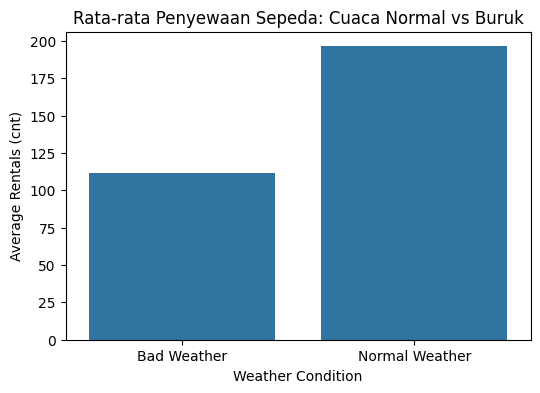

In [330]:
weather_viz = hour_df.copy()
weather_viz['weather_group'] = weather_viz['weathersit'].apply(lambda x: 'Bad Weather' if x >= 3 else 'Normal Weather')

weather_plot = weather_viz.groupby('weather_group')['cnt'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=weather_plot, x='weather_group', y='cnt')

plt.title('Rata-rata Penyewaan Sepeda: Cuaca Normal vs Buruk')
plt.xlabel('Weather Condition')
plt.ylabel('Average Rentals (cnt)')
plt.show()

Cuaca memiliki pengaruh signifikan terhadap jumlah penyewaan sepeda.

Cuaca normal menghasilkan rata-rata penyewaan yang lebih tinggi dibandingkan cuaca buruk, menunjukkan bahwa pengguna cenderung menghindari penggunaan sepeda saat kondisi cuaca tidak mendukung.

### Pertanyaan 2:

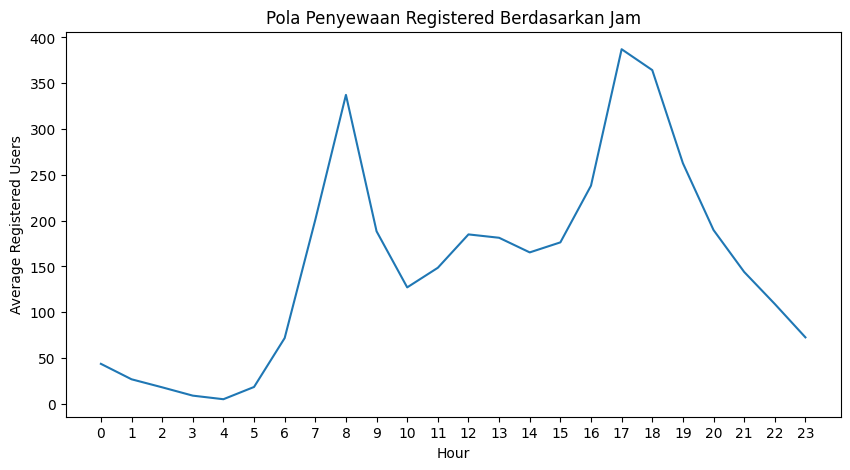

In [331]:
hour_peak = hour_df.groupby('hr')['registered'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=hour_peak, x='hr', y='registered')

plt.title('Pola Penyewaan Registered Berdasarkan Jam')
plt.xlabel('Hour')
plt.ylabel('Average Registered Users')
plt.xticks(range(0,24))
plt.show()

**Insight:** (Opsional)
Terdapat pola jelas pada penggunaan sepeda oleh pengguna registered, dengan dua puncak utama pada pagi hari (sekitar jam 08.00) dan sore hari (sekitar jam 17.00–18.00).

Hal ini mengindikasikan bahwa penggunaan sepeda oleh pengguna registered didominasi oleh aktivitas commuting.

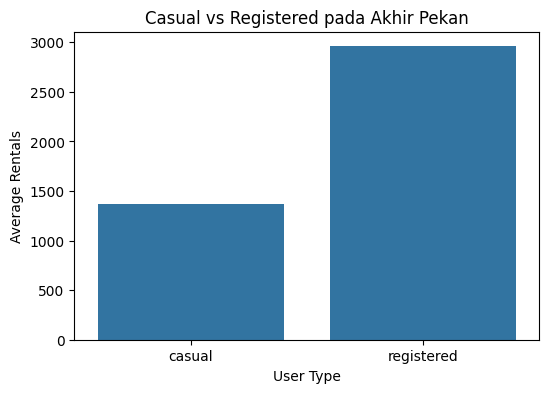

In [332]:
weekend_data = day_df[day_df['workingday'] == 0]

user_viz = weekend_data[['casual','registered']].mean().reset_index()
user_viz.columns = ['user_type','avg_rentals']

plt.figure(figsize=(6,4))
sns.barplot(data=user_viz, x='user_type', y='avg_rentals')

plt.title('Casual vs Registered pada Akhir Pekan')
plt.xlabel('User Type')
plt.ylabel('Average Rentals')
plt.show()

Pada akhir pekan, pengguna registered tetap mendominasi jumlah penyewaan dibandingkan pengguna casual.

Namun, pengguna casual menunjukkan kontribusi yang lebih signifikan dibandingkan hari kerja, yang mengindikasikan bahwa mereka lebih banyak menggunakan sepeda untuk aktivitas rekreasi.


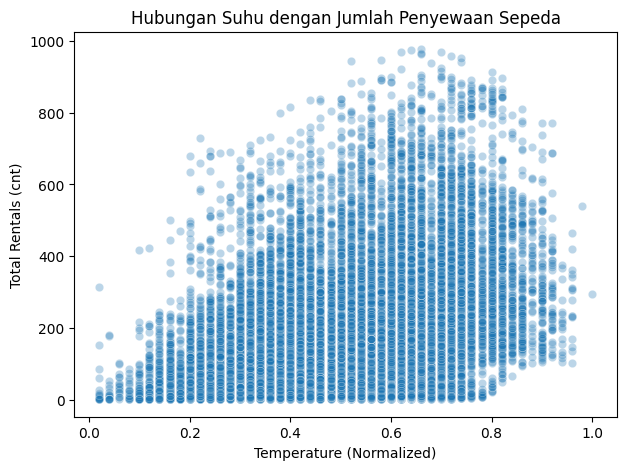

In [333]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=hour_df, x='temp', y='cnt', alpha=0.3)

plt.title('Hubungan Suhu dengan Jumlah Penyewaan Sepeda')
plt.xlabel('Temperature (Normalized)')
plt.ylabel('Total Rentals (cnt)')
plt.show()

Terdapat hubungan positif antara suhu dan jumlah penyewaan sepeda.

Semakin tinggi suhu (hingga titik tertentu), jumlah penyewaan cenderung meningkat. Hal ini menunjukkan bahwa kondisi cuaca yang lebih hangat mendukung aktivitas bersepeda.


## Analisis Lanjutan (Opsional)

#### Binning Analysis (Segmentasi Demand)

In [334]:
all_df['cnt_category'] = pd.qcut(hour_df['cnt'], q=3, labels=['Low Demand', 'Medium Demand', 'High Demand'])

demand_analysis = all_df['cnt_category'].value_counts().reset_index()
demand_analysis.columns = ['demand_level', 'count']
demand_analysis

,demand_level,count
0,Medium Demand,5823
1,Low Demand,5797
2,High Demand,5759


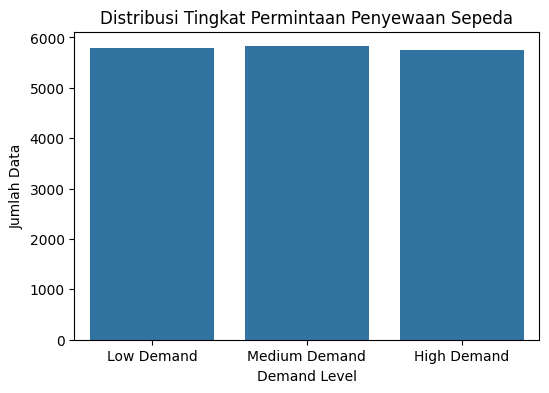

In [335]:
plt.figure(figsize=(6,4))
sns.barplot(data=demand_analysis, x='demand_level', y='count')

plt.title('Distribusi Tingkat Permintaan Penyewaan Sepeda')
plt.xlabel('Demand Level')
plt.ylabel('Jumlah Data')
plt.show()


Sebagian besar data penyewaan berada pada kategori demand menengah hingga tinggi.

Hal ini menunjukkan bahwa layanan bike sharing memiliki tingkat penggunaan yang cukup stabil dan tidak hanya digunakan pada kondisi tertentu saja.


#### Geospatial-style Analysis (Proxy Waktu & Pola Hari)

In [336]:
pivot_table = hour_df.pivot_table(
    values='cnt',
    index='hr',
    columns='workingday',
    aggfunc='mean'
)

pivot_table

/tmp/ipykernel_10620/780271367.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = hour_df.pivot_table(


workingday,0,1
hr,,
0,90.800000,36.786290
1,69.508696,16.552632
2,53.171053,8.683778
3,25.775330,4.942553
4,8.264317,5.429787
5,8.689189,24.913131
6,18.742358,102.500000
7,43.406926,290.612903
8,105.653680,477.006048


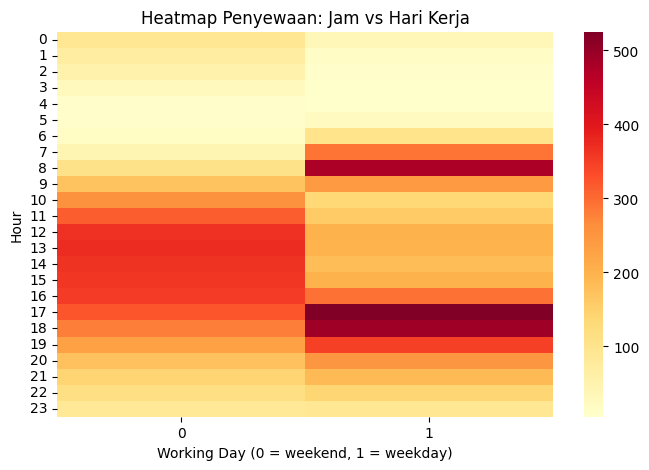

In [337]:
plt.figure(figsize=(8,5))
sns.heatmap(pivot_table, cmap='YlOrRd')

plt.title('Heatmap Penyewaan: Jam vs Hari Kerja')
plt.xlabel('Working Day (0 = weekend, 1 = weekday)')
plt.ylabel('Hour')
plt.show()


Terdapat pola yang jelas bahwa penyewaan sepeda lebih tinggi pada jam-jam tertentu di hari kerja dibandingkan akhir pekan.

Hal ini memperkuat temuan sebelumnya bahwa penggunaan sepeda didominasi oleh aktivitas commuting pada hari kerja.

#### RFM Analysis

In [338]:
rfm_analysis = hour_df.groupby('weekday')['cnt'].agg(['mean','sum','count']).reset_index()
rfm_analysis


,weekday,mean,sum,count
0,0,177.468825,444027,2502
1,1,183.744655,455503,2479
2,2,191.238891,469109,2453
3,3,191.130505,473048,2475
4,4,196.436665,485395,2471
5,5,196.135907,487790,2487
6,6,190.209793,477807,2512


Hari kerja memiliki total penyewaan yang lebih stabil dibandingkan akhir pekan.

Hal ini menunjukkan bahwa penggunaan sepeda lebih konsisten pada hari kerja dibandingkan pola rekreasi di akhir pekan.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Berdasarkan hasil analisis, terdapat perbedaan yang signifikan antara kondisi cuaca normal dan cuaca buruk terhadap jumlah penyewaan sepeda. Cuaca normal menghasilkan rata-rata penyewaan yang jauh lebih tinggi dibandingkan cuaca buruk. Hal ini menunjukkan bahwa kondisi cuaca memiliki pengaruh besar terhadap keputusan pengguna dalam menggunakan layanan bike sharing.
- **Conclusion pertanyaan 2:** Pengguna registered menunjukkan pola penggunaan yang sangat jelas berdasarkan waktu, dengan puncak penyewaan terjadi pada jam 08.00 pagi dan 17.00–18.00 sore. Pola ini mengindikasikan bahwa pengguna registered cenderung menggunakan sepeda untuk aktivitas rutin seperti berangkat dan pulang kerja (commuting).
- **Conclusion pertanyaan 3:** Pada akhir pekan, pengguna registered tetap mendominasi jumlah penyewaan sepeda dibandingkan pengguna casual. Namun, pengguna casual menunjukkan peningkatan kontribusi dibandingkan hari kerja, yang mengindikasikan bahwa mereka lebih sering menggunakan sepeda untuk aktivitas rekreasi di akhir pekan.
- **Conclusion pertanyaan 4:** Terdapat hubungan positif antara suhu dan jumlah penyewaan sepeda. Semakin tinggi suhu (hingga titik tertentu), semakin tinggi pula jumlah penyewaan sepeda. Hal ini menunjukkan bahwa kondisi cuaca yang lebih hangat mendukung aktivitas bersepeda.

**Rekomendasi Action Item:**
1. Menyesuaikan ketersediaan dan operasional bike sharing berdasarkan kondisi cuaca, seperti mengurangi distribusi unit saat cuaca buruk untuk efisiensi operasional.

2. Meningkatkan jumlah armada sepeda pada jam sibuk (08.00 dan 17.00–18.00) untuk menghindari kekurangan unit pada jam commuting.

3. Mengembangkan strategi promosi khusus untuk meningkatkan penggunaan pengguna casual, terutama pada hari kerja.

4. Memanfaatkan kondisi cuaca hangat dan musim tertentu untuk kampanye pemasaran guna meningkatkan jumlah penyewaan sepeda.


In [339]:
day_df.to_csv('day.csv', index=False)
hour_df.to_csv('hour.csv', index=False)